# Energy Thief — Level 2: Adaptive Monitoring (tabular Q-learning)

**Project VFA-4.** Same power grid as Level 1 — a plant feeding **consumers**
through edges that carry **energy flows**, with each edge's overproduction available
as divertible **slack** — but on a **bigger network** and with the brief's **adaptive
monitoring**. Two additions:

1. the plant feeds **two substations**, each serving its own group of consumers, and
   one substation is **watched more closely** than the other;
2. every consumer edge carries a **suspicion** ("heat") that **rises each time it is
   tapped** and **cools when left alone**, inflating that edge's alarm probability.

The suspicion of every edge enters the state, so the state space **explodes**. We
still run **tabular Q-learning** and watch it strain: most states are visited too
rarely to learn. That curse of dimensionality is what motivates function approximation.

## The MDP

Finite MDP on a plant → **two substations** → $n$ consumers grid (default $n=6$, three
per substation). One substation is monitored more closely (a per-substation
sensitivity factor $m_{\text{sub}(c)}$). Each consumer edge $c$ has flow $f_c$, slack
$s_c$ (a function of the demand phase $\phi$), and a **suspicion** $\sigma_c \in \{0,\dots,k-1\}$.

**State space.** Phase, surplus, and the suspicion of *every* edge:
$$s = (\phi,\ U,\ \sigma_1,\dots,\sigma_n), \qquad |\mathcal{S}| = n_\phi\,(U_{\max}+1)\,k^{n}.$$
With $n_\phi=4$, $U_{\max}=8$, $k=3$, $n=6$: $|\mathcal{S}| = 4\cdot 9\cdot 3^6 = 26{,}244$ —
against $36$ at Level 1. The exponential $k^{n}$ is the curse.

**Actions.** Skim / overdraw each consumer edge, or lie-low: $|\mathcal{A}| = 2n+1 = 13$.

**Transitions.** As Level 1 (phase random walk; a tap diverts slack, an overdraw
causes a shortfall $h$), but the alarm probability is inflated by the substation
factor and the tapped edge's suspicion:
$$p = \min\!\big(1,\ \varsigma(\phi)\,m_{\text{sub}(c)}\,(\beta_0 + \beta_h\,h)\,(1 + \beta_\sigma\,\sigma_c)\big),$$
and the tap **raises that edge's suspicion**, $\sigma_c \leftarrow \min(\sigma_c+1,k-1)$;
every **other** edge **cools** by one level with probability $c$ per step.

*Units.* As Level 1, energy is shown in **megawatts (MW)** at **1 unit = 5 MW** (surplus
cap = 40 MW), and the per-episode **return** (surplus over 50 one-hour steps) is in **MWh**.

**Reward.** As Level 1: $R = U'$, the surplus held after the step; an alarm sets
$U'=0$. Accumulate a large surplus and avoid losing it.

**Objective.** Learn $q_\star$ and act greedily. Because tapping an edge raises its own
future risk, the optimal policy must **rotate across edges** and favour the cheaper
substation — the diversification the brief's challenging variant is meant to force.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from energy_thief.envs import GridThiefEnvL2, ACTION_NAMES_L2
from energy_thief.agents import QLearningAgent

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

# Display scale: 1 abstract energy unit = 5 megawatts (substation-feeder scale).
# Purely for labels — the environment's dynamics use the raw integer units.
MW = 5

In [2]:
env = GridThiefEnvL2(seed=1)
print(f"states: {env.n_states}   actions: {env.n_actions}")
print(f"consumers: {env.consumers}")
for s in range(env.n_substations):
    members = [env.consumers[i] for i in range(env.n_consumers) if env.substation_of[i] == s]
    print(f"  {env.substations[s]} (monitoring x{env.substation_sens[s]:g}): {members}")
print(f"suspicion levels k = {env.k}  (risk x (1 + {env.susp_factor:g}*sigma)),  cool prob = {env.cool_prob}")
print(f"|S| = n_phase x (U_max+1) x k^n = {env.n_phase} x {env.surplus_max+1} x {env.k}^{env.n_consumers} = {env.n_states}")
print(env.render())

states: 26244   actions: 13
consumers: ('C1', 'C2', 'C3', 'C4', 'C5', 'C6')
  S1 (monitoring x1): ['C1', 'C2', 'C3']
  S2 (monitoring x1.3): ['C4', 'C5', 'C6']
suspicion levels k = 3  (risk x (1 + 1*sigma)),  cool prob = 0.3
|S| = n_phase x (U_max+1) x k^n = 4 x 9 x 3^6 = 26244
t=0   phase=0 surplus=0/8  heat[C10 C20 C30 C40 C50 C60]  [S1:C1C2C3  S2:C4C5C6]


## The environment at a glance

**Left:** the network — a plant feeds **two substations**, each serving three
consumers; **S2 is monitored more closely** ($\times 1.3$), so its consumers are
riskier to tap. **Middle:** the divertible **slack** on each edge per demand phase,
labelled by substation. **Right:** the Level-2 twist — for an **overdraw**, suspicion
multiplies the alarm probability by $(1+\beta_\sigma\sigma)$ (shown for an S1 edge;
$\times 1.3$ again for S2), so an edge tapped repeatedly becomes almost certain to
trip the alarm, pushing the thief to spread its taps across the grid.

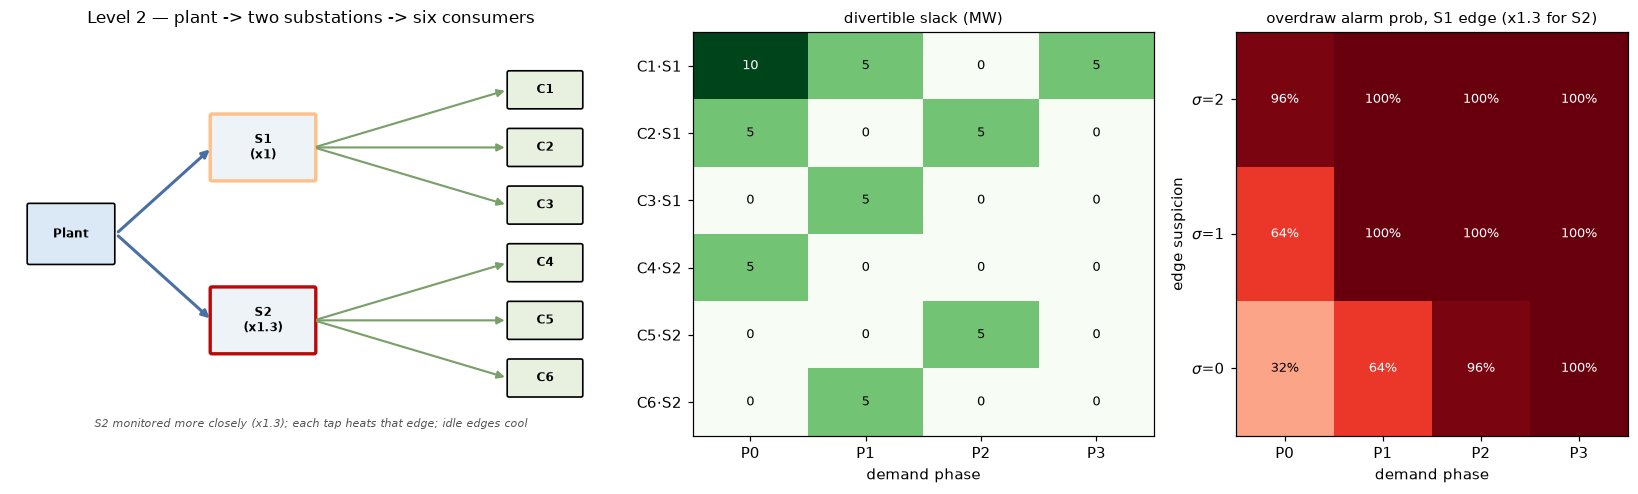

In [3]:
fig, (axS, axK, axH) = plt.subplots(1, 3, figsize=(15, 4.6),
                                    gridspec_kw={"width_ratios": [1.3, 1, 0.85]})
n = env.n_consumers

# Panel 1: network schematic with two substations
axS.set_xlim(0, 10); axS.set_ylim(0, n + 1.0); axS.axis("off")
def box(x, y, w, h, label, fc, ec="black", lw=1.1):
    axS.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.03",
                  fc=fc, ec=ec, lw=lw))
    axS.text(x, y, label, ha="center", va="center", fontsize=8, weight="bold")
cons_y = {i: n - i for i in range(n)}
ymid = (n + 1.0) / 2
box(1.0, ymid, 1.4, 1.0, "Plant", "#dbe9f6")
sub_cmap = plt.get_cmap("OrRd"); maxf = max(env.substation_sens)
for s in range(env.n_substations):
    members = [i for i in range(n) if env.substation_of[i] == s]
    sy = float(np.mean([cons_y[i] for i in members])); factor = env.substation_sens[s]
    ec = sub_cmap(0.35 + 0.5 * (factor - 1.0) / max(1e-9, maxf - 1.0))
    box(4.2, sy, 1.7, 1.1, f"{env.substations[s]}\n(x{factor:g})", "#eef3f8", ec=ec, lw=2.2)
    axS.annotate("", xy=(3.35, sy), xytext=(1.75, ymid),
                 arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#4a6fa5"))
    for i in members:
        box(8.9, cons_y[i], 1.2, 0.6, env.consumers[i], "#e8f0e0")
        axS.annotate("", xy=(8.28, cons_y[i]), xytext=(5.05, sy),
                     arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#7aa06a"))
axS.set_title("Level 2 — plant -> two substations -> six consumers", fontsize=11)
axS.text(5.0, 0.15, "S2 monitored more closely (x1.3); each tap heats that edge; idle edges cool",
         ha="center", fontsize=7.5, style="italic", color="#555")

# Panel 2: slack per (consumer x phase), labelled by substation
axK.imshow(env.slack.T, cmap="Greens", aspect="auto", vmin=0, vmax=max(1, env.slack.max()))
for i in range(n):
    for ph in range(env.n_phase):
        axK.text(ph, i, str(env.slack[ph, i]*MW), ha="center", va="center", fontsize=8.5,
                 color="white" if env.slack[ph, i] > env.slack.max()*0.6 else "black")
axK.set_xticks(range(env.n_phase)); axK.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axK.set_yticks(range(n))
axK.set_yticklabels([f"{env.consumers[i]}·{env.substations[env.substation_of[i]]}" for i in range(n)])
axK.set_xlabel("demand phase"); axK.set_title("divertible slack (MW)", fontsize=10)

# Panel 3: suspicion inflates overdraw risk (sigma x phase) for an S1 edge
sus_risk = np.array([[min(1.0, env.sens[ph] * (env.base_divert + env.shortfall_weight * env.overdraw_extra)
                          * (1 + env.susp_factor * s)) for ph in range(env.n_phase)]
                     for s in range(env.k)])
axH.imshow(sus_risk, cmap="Reds", aspect="auto", vmin=0, vmax=1, origin="lower")
for s in range(env.k):
    for ph in range(env.n_phase):
        axH.text(ph, s, f"{sus_risk[s, ph]*100:.0f}%", ha="center", va="center", fontsize=8.5,
                 color="white" if sus_risk[s, ph] > 0.5 else "black")
axH.set_xticks(range(env.n_phase)); axH.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axH.set_yticks(range(env.k)); axH.set_yticklabels([f"$\\sigma$={s}" for s in range(env.k)])
axH.set_xlabel("demand phase"); axH.set_ylabel("edge suspicion")
axH.set_title("overdraw alarm prob, S1 edge (x1.3 for S2)", fontsize=10)
fig.tight_layout(); plt.show()

## Tabular Q-learning

We run the **same** tabular agent as Level 1, updating $Q(S_t,A_t)$ by the one-sample
Bellman target. Only the environment is harder: the table now has
$26{,}244 \times 13 \approx 3.4\times10^5$ entries, and we track how much of it
training reaches.

## Training loop

Same loop as Level 1 (5 seeds), plus we record visited states for a **coverage**
measure, and anneal $\varepsilon$ more slowly since there is far more to explore.

In [4]:
def evaluate(env, agent, n_episodes=1000):
    rets = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s, greedy=True)
            s, r, term, trunc, _ = env.step(a)
            g, done = g + r, term or trunc
        rets[ep] = g
    return rets.mean(), rets.std()


def train(env, n_episodes, seed, eval_env=None, eval_every=250, eval_episodes=50, **kw):
    agent = QLearningAgent(env.n_states, env.action_space.n, seed=seed, **kw)
    returns = np.empty(n_episodes)
    epsilons = np.empty(n_episodes)
    eval_x, eval_y = [], []
    visited = set()
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            visited.add(s)
            a = agent.select_action(s)
            s2, r, term, trunc, _ = env.step(a)
            agent.update(s, a, r, s2, term)
            s, g, done = s2, g + r, term or trunc
        returns[ep] = g
        epsilons[ep] = agent.epsilon
        agent.end_episode()
        if eval_env is not None and (ep + 1) % eval_every == 0:
            m, _ = evaluate(eval_env, agent, eval_episodes)
            eval_x.append(ep + 1); eval_y.append(m)
    return agent, returns, np.array(eval_x), np.array(eval_y), epsilons, len(visited)

In [5]:
N_EPISODES = 8000
SEEDS = range(5)
HP = dict(alpha=0.1, gamma=0.99, epsilon_decay=0.9995)

curves, eval_curves, agents, coverage = [], [], [], []
eval_x, epsilons = None, None
for seed in SEEDS:
    agent, returns, ex, ey, eps, nvis = train(
        GridThiefEnvL2(seed=1), N_EPISODES, seed=seed, eval_env=GridThiefEnvL2(seed=1), **HP)
    curves.append(returns); eval_curves.append(ey); agents.append(agent); coverage.append(nvis)
    eval_x = ex
    epsilons = eps if epsilons is None else epsilons
curves = np.array(curves); eval_curves = np.array(eval_curves)
print("training done:", curves.shape)

training done: (5, 8000)


## Learning curve

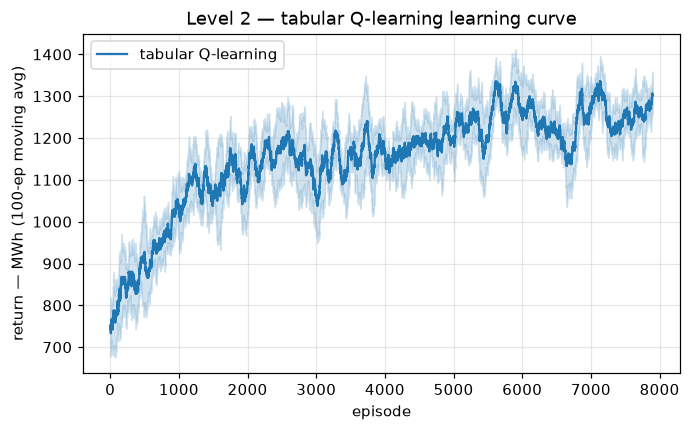

In [6]:
def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

smoothed = np.array([moving_average(c) for c in curves])
mean, std = smoothed.mean(0), smoothed.std(0)
x = np.arange(smoothed.shape[1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, mean * MW, color="C0", label="tabular Q-learning")
ax.fill_between(x, (mean - std) * MW, (mean + std) * MW, color="C0", alpha=0.2)
ax.set_xlabel("episode"); ax.set_ylabel("return — MWh (100-ep moving avg)")
ax.set_title("Level 2 — tabular Q-learning learning curve")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## Greedy evaluation return

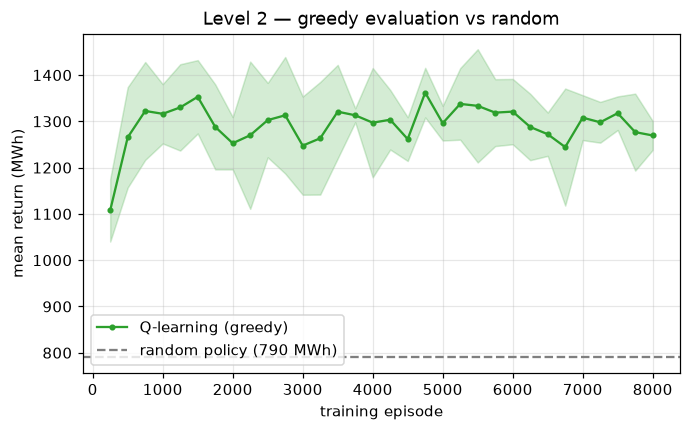

final greedy return: +1270 ± 31 MWh   (random +790 MWh)


In [7]:
ev_mean, ev_std = eval_curves.mean(0), eval_curves.std(0)

def random_return(env, n=1000):
    r = np.empty(n)
    for i in range(n):
        s, _ = env.reset(); done, g = False, 0.0
        while not done:
            a = int(rng.integers(env.n_actions))
            s, rr, term, trunc, _ = env.step(a); g += rr; done = term or trunc
        r[i] = g
    return r.mean(), r.std()
rand_m, rand_s = random_return(GridThiefEnvL2(seed=1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eval_x, ev_mean * MW, color="C2", marker="o", ms=3, label="Q-learning (greedy)")
ax.fill_between(eval_x, (ev_mean - ev_std) * MW, (ev_mean + ev_std) * MW, color="C2", alpha=0.2)
ax.axhline(rand_m * MW, ls="--", color="C7", label=f"random policy ({rand_m*MW:.0f} MWh)")
ax.set_xlabel("training episode"); ax.set_ylabel("mean return (MWh)")
ax.set_title("Level 2 — greedy evaluation vs random")
ax.legend(); ax.grid(alpha=0.3); plt.show()
print(f"final greedy return: {ev_mean[-1]*MW:+.0f} ± {ev_std[-1]*MW:.0f} MWh   (random {rand_m*MW:+.0f} MWh)")

## Exploration schedule

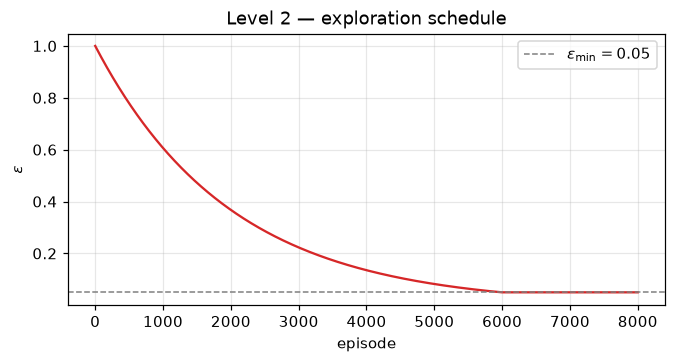

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.arange(len(epsilons)), epsilons, color="C3")
ax.axhline(agents[0].epsilon_min, ls="--", color="grey", lw=1,
           label=fr"$\varepsilon_{{\min}} = {agents[0].epsilon_min}$")
ax.set_xlabel("episode"); ax.set_ylabel(r"$\varepsilon$")
ax.set_title("Level 2 — exploration schedule")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## The curse of dimensionality

The Level-2 story in one number: **how much of the Q-table training ever reaches.**
At Level 1 all 36 states were visited many times. Here the table is thousands of times
larger, and even after 5 × 8000 episodes a large fraction is **never touched** — those
entries stay at their initial value. Tabular Q-learning still learns on the slice it
visits, but the empty fraction only grows as the network gets bigger, which is why the
table does not scale.

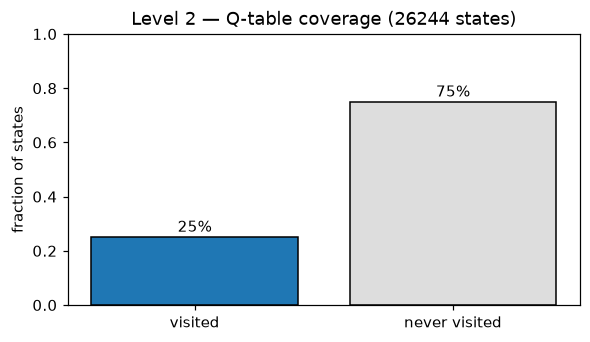

states visited: 6577 / 26244 = 25.1% (mean over seeds)


In [9]:
cov = np.array(coverage); frac = cov / env.n_states
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(["visited", "never visited"], [frac.mean(), 1 - frac.mean()],
       color=["C0", "#ddd"], edgecolor="black")
ax.set_ylabel("fraction of states"); ax.set_ylim(0, 1)
ax.set_title(f"Level 2 — Q-table coverage ({env.n_states} states)")
for i, v in enumerate([frac.mean(), 1 - frac.mean()]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.show()
print(f"states visited: {cov.mean():.0f} / {env.n_states} = {frac.mean():.1%} (mean over seeds)")

## The learned policy (a slice)

The full state is high-dimensional, so we show the slice with **all edges cold**
($\sigma=0$): the greedy action over $(\text{phase}, \text{surplus})$ (**sk**/**ov** =
skim/overdraw a consumer, **low** = lie low). As at Level 1, the thief overdraws when
it has little surplus to lose and skims / lies low to protect a large stash. The
**high-surplus corner** is rarely reached with all edges cold (you build surplus *by*
tapping, which heats edges), so those cells are under-visited — a noisy estimate that
is itself a symptom of the coverage gap above.

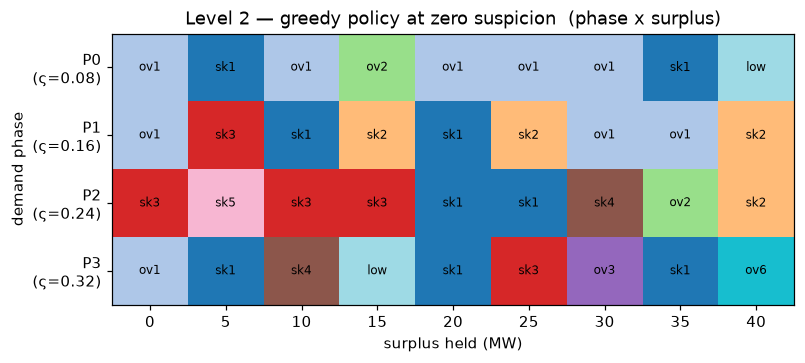

In [10]:
KE = env.k ** env.n_consumers
def obs_zero_susp(P, U):
    return (P * (env.surplus_max + 1) + U) * KE
def short(a):
    if a == env.LIE_LOW: return "low"
    c, ov = divmod(a, 2)
    return f"{'ov' if ov else 'sk'}{c+1}"

policy = np.array([[int(agents[0].Q[obs_zero_susp(P, U)].argmax())
                    for U in range(env.surplus_max + 1)] for P in range(env.n_phase)])
cmap = plt.get_cmap("tab20", env.n_actions)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.imshow(policy, cmap=cmap, vmin=0, vmax=env.n_actions - 1, aspect="auto")
for P in range(env.n_phase):
    for U in range(env.surplus_max + 1):
        ax.text(U, P, short(policy[P, U]), ha="center", va="center", fontsize=8)
ax.set_xticks(range(env.surplus_max + 1)); ax.set_yticks(range(env.n_phase))
ax.set_xticklabels([U * MW for U in range(env.surplus_max + 1)])
ax.set_yticklabels([f"P{P}\n(ς={env.sens[P]:.2f})" for P in range(env.n_phase)])
ax.set_xlabel("surplus held (MW)"); ax.set_ylabel("demand phase")
ax.set_title("Level 2 — greedy policy at zero suspicion  (phase x surplus)")
plt.show()

## A single shift, step by step

One greedy episode. Top: the demand phase. Middle: the surplus (reward), with alarms
($\times$). Bottom: the **suspicion of every edge over time** — the Level-2 signature.
Watch the thief **rotate across edges** so none stays hot, keeping its alarm risk
manageable.

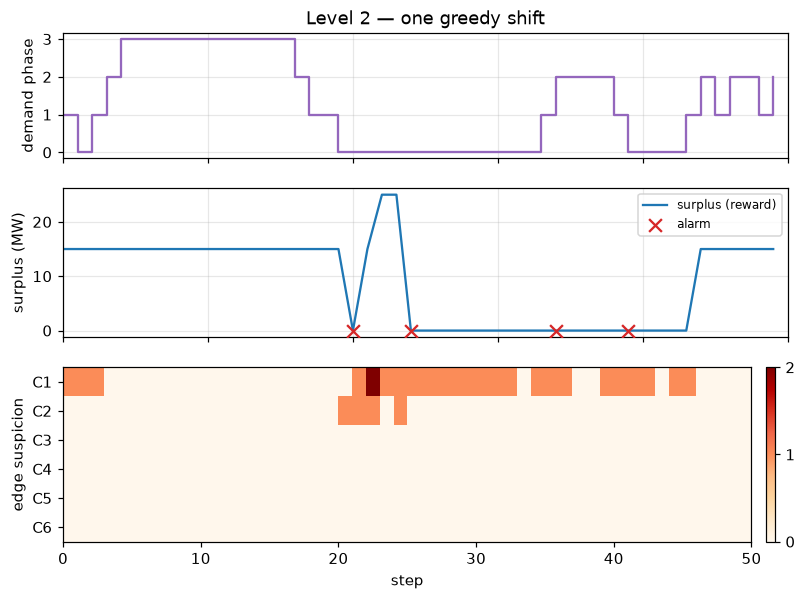

In [11]:
def greedy_trace(env, agent):
    s, _ = env.reset()
    phases, surplus, alarms, susp_hist = [], [], [], []
    done, t = False, 0
    while not done:
        a = agent.select_action(s, greedy=True)
        s, r, term, trunc, info = env.step(a)
        phases.append(info["phase"]); surplus.append(info["surplus"])
        susp_hist.append(info["suspicion"])
        if info["alarm"]: alarms.append(t)
        done, t = term or trunc, t + 1
    return np.array(phases), np.array(surplus), alarms, np.array(susp_hist).T

phases, surplus, alarms, susp_hist = greedy_trace(GridThiefEnvL2(seed=7), agents[0])
steps = np.arange(len(phases))

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(8.5, 6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1.2, 1.4]})
a1.step(steps, phases, where="post", color="C4"); a1.set_ylabel("demand phase")
a1.set_yticks(range(env.n_phase)); a1.grid(alpha=0.3)
a1.set_title("Level 2 — one greedy shift")

a2.plot(steps, surplus * MW, color="C0", label="surplus (reward)")
if alarms:
    a2.scatter(alarms, np.zeros(len(alarms)), marker="x", color="C3", s=70, zorder=3, label="alarm")
a2.set_ylabel("surplus (MW)"); a2.grid(alpha=0.3); a2.legend(loc="upper right", fontsize=8)

im = a3.imshow(susp_hist, cmap="OrRd", aspect="auto", vmin=0, vmax=env.k - 1,
               extent=[0, len(phases), env.n_consumers - 0.5, -0.5])
a3.set_yticks(range(env.n_consumers)); a3.set_yticklabels(env.consumers)
a3.set_ylabel("edge suspicion"); a3.set_xlabel("step")
fig.colorbar(im, ax=a3, fraction=0.03, pad=0.02, ticks=range(env.k))
plt.show()

## Takeaways

- **Tabular Q-learning still runs and still beats random** on Level 2, learning a
  diversifying, substation-aware policy — but the table is already largely **empty**
  (coverage plot), because suspicion makes the state space grow as $k^{n}$.
- Unvisited states get **no learning at all** — a table cannot generalize from a
  visited state to a similar unvisited one. That is the **curse of dimensionality**:
  more edges ⇒ exponentially more states ⇒ a table that can neither fit in memory nor
  be visited enough.
- **Next:** replace the table with **linear function approximation** over hand-crafted
  features (slack / expected value of the tap, local vs. aggregate suspicion,
  substation factor, surplus, phase). Features let the agent **generalize** across
  near-identical states instead of memorizing each — the natural fit for Level 2.

## Watch a heist, step by step

A frame-by-frame replay of one greedy episode on the two-substation network. The
tapped line is highlighted (green = **skim**, orange = **overdraw**), each consumer box
is shaded by its **suspicion** (heat, with $\sigma$ shown at right), the **surplus
gauge** fills and empties, and an **ALARM** banner flashes on a bust. Watch the thief
rotate across edges so none stays hot, and favour S1 over the more-watched S2.

To watch it live in a running kernel (the lecture's `clear_output` style):

```python
from IPython.display import clear_output
import time
for snap in snaps:
    fig, ax = plt.subplots(figsize=(8.5, 4.6)); draw_scene(ax, viz_env, snap)
    plt.show(); clear_output(wait=True); time.sleep(0.3)
```

In [12]:
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from IPython.display import HTML

def draw_scene(ax, env, snap):
    ax.clear()
    n = env.n_consumers
    ax.set_xlim(0, 11); ax.set_ylim(0, n + 2.2); ax.axis("off")
    phase, U = snap["phase"], snap["surplus"]
    tapped, ov, alarm = snap["tapped"], snap["overdraw"], snap["alarm"]
    susp = snap.get("susp")
    subof = getattr(env, "substation_of", None)
    slack = env.slack[phase]; smax = max(1, int(env.slack.max())); ymid = (n + 2.2) / 2
    def box(x, y, w, h, label, fc, ec="black", lw=1.1, fs=8):
        ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.03", fc=fc, ec=ec, lw=lw))
        ax.text(x, y, label, ha="center", va="center", fontsize=fs, weight="bold")
    box(1.0, ymid, 1.4, 1.0, "Plant", "#dbe9f6"); hub_x = 3.9
    if subof is not None:
        sub_y = {}
        for s in range(env.n_substations):
            members = [i for i in range(n) if subof[i] == s]
            sy = float(np.mean([n - i + 0.9 for i in members])); sub_y[s] = sy
            box(hub_x, sy, 1.5, 1.0, f"{env.substations[s]}\n(x{env.substation_sens[s]:g})", "#eef3f8")
            ax.annotate("", xy=(hub_x - 0.8, sy), xytext=(1.72, ymid), arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#4a6fa5"))
    else:
        sub_y = None
        box(hub_x, ymid, 1.6, 1.1, "Sub-\nstation", "#dbe9f6")
        ax.annotate("", xy=(hub_x - 0.85, ymid), xytext=(1.72, ymid), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#4a6fa5"))
    green = plt.get_cmap("Greens")
    for i, c in enumerate(env.consumers):
        y = n - i + 0.9; sy = sub_y[subof[i]] if sub_y is not None else ymid
        hl = (i == tapped)
        ecol = ("#e6550d" if ov else "#2ca25f") if hl else green(0.25 + 0.6 * slack[i] / smax)
        ax.annotate("", xy=(8.15, y), xytext=(hub_x + 0.8, sy), arrowprops=dict(arrowstyle="-|>", lw=4.0 if hl else 1.6, color=ecol))
        cfc = plt.get_cmap("OrRd")(0.15 + 0.5 * susp[i] / max(1, env.k - 1)) if susp is not None else "#e8f0e0"
        if hl and alarm: cfc = "#ff8a8a"
        box(8.9, y, 1.5, 0.72, c, cfc)
        ax.text(6.5, y + 0.16, f"spare {slack[i]*MW} MW", fontsize=7, color="#444", ha="center")
        if susp is not None: ax.text(10.0, y, f"σ{susp[i]}", fontsize=7, color="#a33", va="center")
        if hl: ax.text(6.5, y - 0.24, "OVERDRAW" if ov else "SKIM", fontsize=8, weight="bold", color=ecol, ha="center")
    barx, barw = 2.2, 6.2
    ax.text(0.2, 0.55, "surplus", fontsize=9, va="center")
    ax.add_patch(Rectangle((barx, 0.35), barw, 0.5, fill=False, ec="black"))
    ax.add_patch(Rectangle((barx, 0.35), barw * U / env.surplus_max, 0.5, fc="#4a90d9"))
    ax.text(barx + barw + 0.25, 0.6, f"{U*MW}/{env.surplus_max*MW} MW", va="center", fontsize=9)
    ax.text(hub_x, n + 1.9, f"demand phase {phase}   (sensitivity {env.sens[phase]:.2f})", ha="center", fontsize=8, color="#555")
    if alarm:
        ax.text(5.5, ymid + 1.4, "ALARM — surplus wiped", ha="center", fontsize=13, weight="bold",
                color="white", bbox=dict(boxstyle="round", fc="#d62728", ec="none"))

def rollout(env, agent, seed=123, max_steps=50):
    obs, _ = env.reset(seed=seed)
    snaps = [dict(step=0, action=None, reward=0.0, ret=0.0, phase=env.phase, surplus=env.surplus,
                  tapped=-1, overdraw=False, alarm=False, susp=(env.susp.copy() if hasattr(env, "susp") else None))]
    ret = 0.0
    for t in range(max_steps):
        a = agent.select_action(obs, greedy=True)
        obs, r, term, trunc, info = env.step(a); ret += r
        snaps.append(dict(step=t+1, action=a, reward=r, ret=ret, phase=info["phase"], surplus=info["surplus"],
                          tapped=info["tapped"], overdraw=(a % 2 == 1 and a != env.LIE_LOW), alarm=info["alarm"],
                          susp=(info["suspicion"].copy() if "suspicion" in info else None)))
        if term or trunc: break
    return snaps

viz_env = GridThiefEnvL2(seed=1)
NAMES = ACTION_NAMES_L2
snaps = rollout(viz_env, agents[0], seed=123)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
def update(i):
    draw_scene(ax, viz_env, snaps[i]); s = snaps[i]
    an = "start" if s["action"] is None else NAMES[s["action"]]
    ax.set_title(f"step {s['step']} | {an} | reward={s['reward']:.0f} | return={s['ret']:.0f}", fontsize=10)
ani = animation.FuncAnimation(fig, update, frames=len(snaps), interval=350)
plt.close(fig)
HTML(ani.to_jshtml(fps=3))